In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv("../../datasets/movies.csv")

# Exploratory Data Analysis - Movies Dataset

In [76]:
df.head()

,Title,Rating,Year,Month,Certificate,Runtime,Directors,Stars,Genre,Filming_location,Budget,Income,Country_of_origin
0,Avatar: The Way of Water,7.8,2022,December,PG-13,192,James Cameron,"Sam Worthington, Zoe Saldana, Sigourney Weaver...","Action, Adventure, Fantasy",New Zealand,"$350,000,000","$2,267,946,983",United States
1,Guillermo del Toro's Pinocchio,7.6,2022,December,PG,117,"Guillermo del Toro, Mark Gustafson","Ewan McGregor, David Bradley, Gregory Mann, Bu...","Animation, Drama, Family",USA,"$35,000,000","$108,967","United States, Mexico, France"
2,Bullet Train,7.3,2022,August,R,127,David Leitch,"Brad Pitt, Joey King, Aaron Taylor Johnson, Br...","Action, Comedy, Thriller",Japan,"$85,900,000","$239,268,602","Japan, United States"
3,The Banshees of Inisherin,7.8,2022,November,R,114,Martin McDonagh,"Colin Farrell, Brendan Gleeson, Kerry Condon, ...","Comedy, Drama",Ireland,Unknown,"$19,720,823","Ireland, United Kingdom, United States"
4,M3gan,6.4,2022,December,PG-13,102,Gerard Johnstone,"Jenna Davis, Amie Donald, Allison Williams, Vi...","Horror, Sci-Fi, Thriller",New Zealand,"$12,000,000","$171,253,910",United States


In [77]:
df.shape

(2000, 13)

In [78]:
df.columns

Index(['Title', 'Rating', 'Year', 'Month', 'Certificate', 'Runtime',
       'Directors', 'Stars', 'Genre', 'Filming_location', 'Budget', 'Income',
       'Country_of_origin'],
      dtype='str')

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              2000 non-null   str    
 1   Rating             1999 non-null   float64
 2   Year               2000 non-null   int64  
 3   Month              2000 non-null   str    
 4   Certificate        1966 non-null   str    
 5   Runtime            2000 non-null   str    
 6   Directors          2000 non-null   str    
 7   Stars              2000 non-null   str    
 8   Genre              2000 non-null   str    
 9   Filming_location   2000 non-null   str    
 10  Budget             2000 non-null   str    
 11  Income             2000 non-null   str    
 12  Country_of_origin  2000 non-null   str    
dtypes: float64(1), int64(1), str(11)
memory usage: 203.3 KB


In [80]:
df.describe()

,Rating,Year
count,1999.000000,2000.000000
mean,6.661631,2012.500000
std,0.911507,5.767723
min,1.900000,2003.000000
25%,6.100000,2007.750000
50%,6.700000,2012.500000
75%,7.300000,2017.250000
max,9.000000,2022.000000


## Data Cleaning

In [81]:
df.isnull().sum()

Title                 0
Rating                1
Year                  0
Month                 0
Certificate          34
Runtime               0
Directors             0
Stars                 0
Genre                 0
Filming_location      0
Budget                0
Income                0
Country_of_origin     0
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(0)

## Visualizations

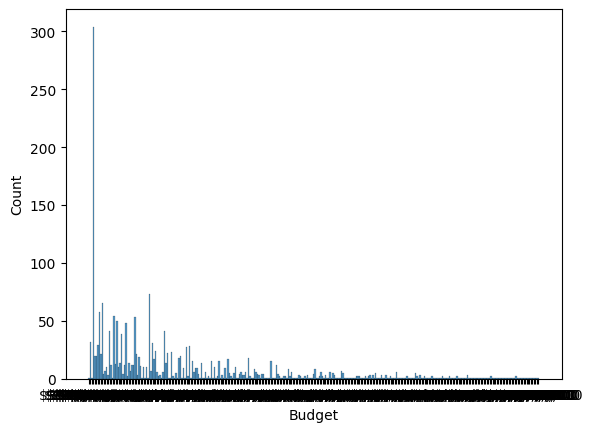

In [83]:
sns.histplot(df["Budget"])
plt.show()

In [84]:
df.columns = df.columns.str.lower()
df.columns

Index(['title', 'rating', 'year', 'month', 'certificate', 'runtime',
       'directors', 'stars', 'genre', 'filming_location', 'budget', 'income',
       'country_of_origin'],
      dtype='str')

In [85]:
df.corr(numeric_only=True)

,rating,year
rating,1.000000,-0.014964
year,-0.014964,1.000000


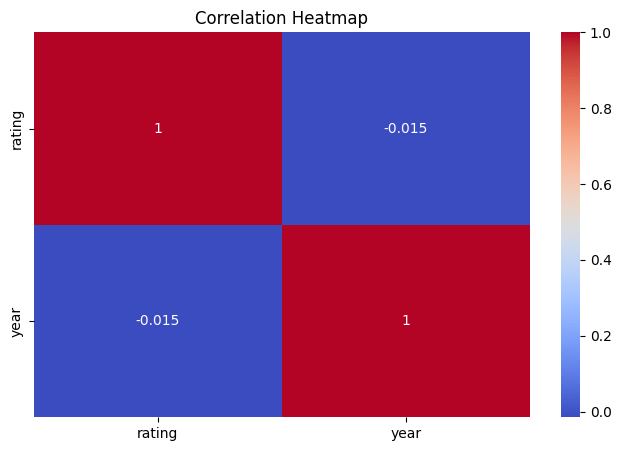

In [86]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

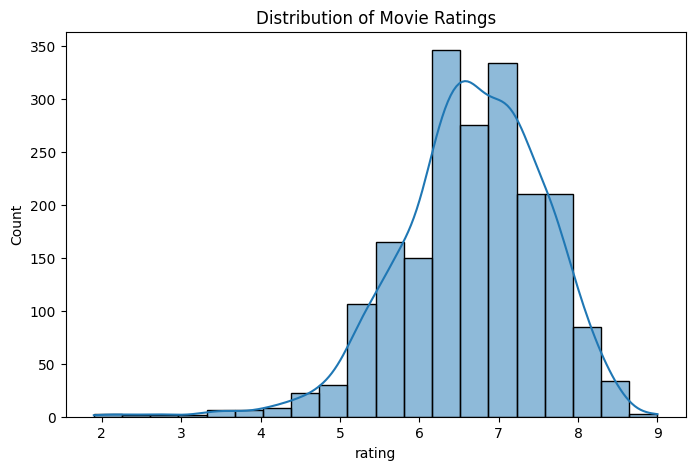

In [87]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

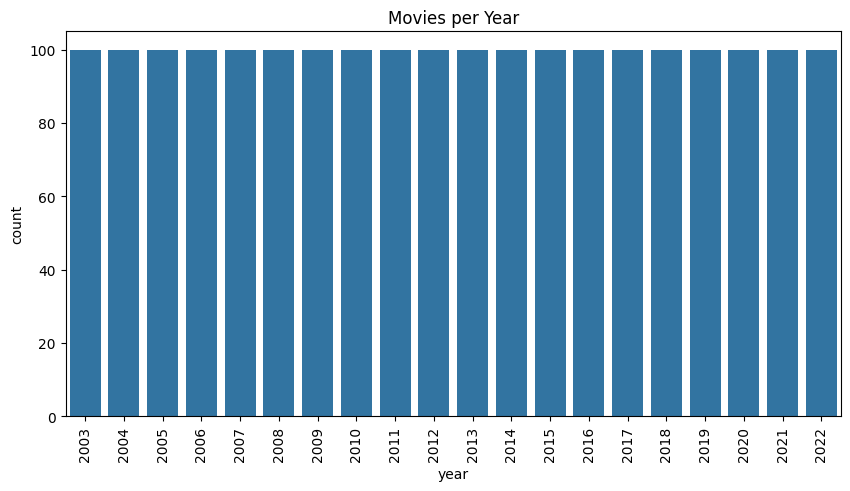

In [88]:
plt.figure(figsize=(10,5))
sns.countplot(x=df["year"])
plt.xticks(rotation=90)
plt.title("Movies per Year")
plt.show()

In [89]:
df["genre"].value_counts().head(10)

genre
Action, Adventure, Sci-Fi       92
Animation, Adventure, Comedy    77
Comedy, Drama, Romance          76
Drama                           65
Action, Adventure, Fantasy      59
Comedy                          57
Comedy, Romance                 56
Action, Adventure, Comedy       55
Drama, Romance                  53
Comedy, Drama                   50
Name: count, dtype: int64

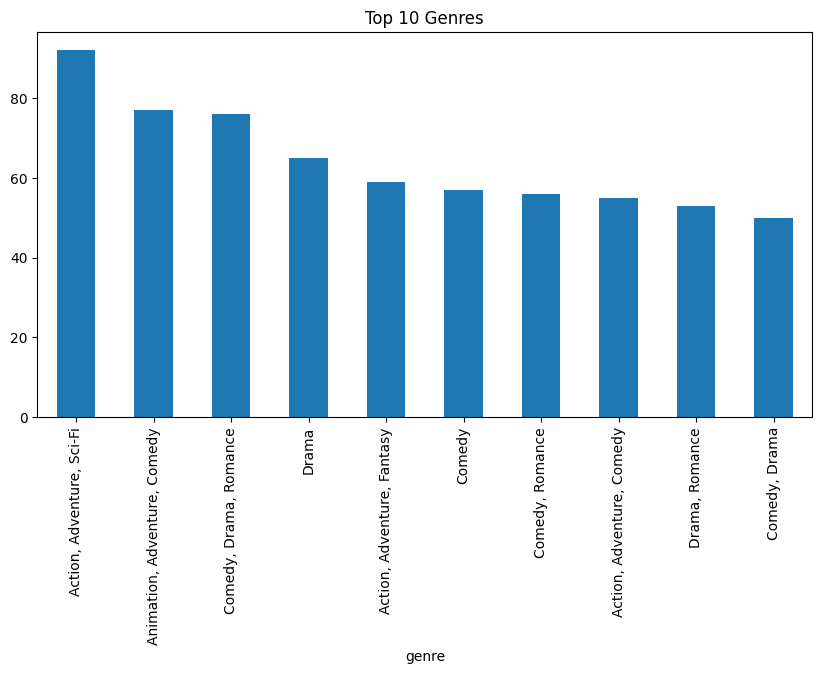

In [90]:
plt.figure(figsize=(10,5))
df["genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

## Budget vs Income Analysis

The scatterplot shows a positive relationship between movie budgets and income. 
Movies with larger budgets tend to generate higher revenues, although the relationship is not perfectly linear.

Several outliers can be observed, representing blockbuster movies with extremely high income.

Lower-budget movies are more concentrated in the lower-left area of the plot, indicating lower revenues overall.

In [93]:
df[["budget", "income"]].dtypes

budget    str
income    str
dtype: object

In [94]:
df["budget"] = (
    df["budget"]
    .astype(str)
    .replace(r'[\$,]', '', regex=True)
)

df["income"] = (
    df["income"]
    .astype(str)
    .replace(r'[\$,]', '', regex=True)
)

In [95]:
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["income"] = pd.to_numeric(df["income"], errors="coerce")

In [96]:
df[["budget", "income"]].dtypes

budget    float64
income    float64
dtype: object

In [97]:
df["profit"] = df["income"] - df["budget"]

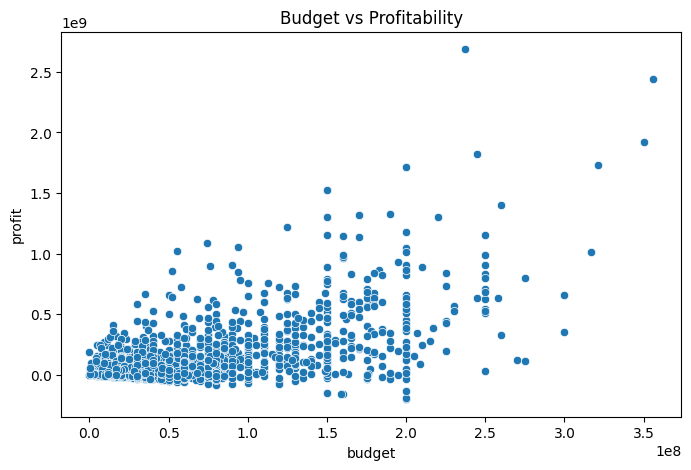

In [98]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="budget", y="profit")
plt.title("Budget vs Profitability")
plt.show()

# Conclusions

This exploratory data analysis revealed several interesting insights about the movie dataset.

## Key Findings

- Most movie ratings are concentrated between **6 and 7.5**, indicating generally positive audience reception.
- The correlation analysis showed that **movie release year has almost no relationship with ratings**.
- Budget and income present a **positive relationship**, suggesting that movies with larger budgets tend to generate higher revenues.
- The profitability analysis demonstrated that **high budgets do not always guarantee higher profit**, although blockbuster productions often achieve the largest returns.
- A few significant outliers were identified, representing movies with exceptionally high income compared to the rest of the dataset.

## Data Quality Observations

- Some columns contained missing values, especially in the `certificate` field.
- Financial columns such as `budget` and `income` required cleaning and conversion from text format to numeric values before analysis.

## Skills Practiced

During this notebook, the following data analysis techniques were applied:

- Data loading with Pandas
- Dataset inspection and cleaning
- Missing value analysis
- Descriptive statistics
- Histograms and distribution analysis
- Correlation heatmaps
- Countplots and categorical visualizations
- Scatterplots for relationship analysis
- Feature engineering (`profit = income - budget`)

## Final Reflection

This dataset provided a practical example of a complete EDA workflow, combining data cleaning, visualization, interpretation of relationships, and extraction of meaningful insights using Python libraries such as Pandas, Matplotlib, and Seaborn.